# 04 — Machine Learning Models

XGBoost (with a small chronological grid search) and a Random Forest, evaluated with the same walk-forward protocol as the statistical models. Hyperparameters are selected on the validation block only — the test set is never touched during tuning.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.figsize": (11, 5), "figure.dpi": 100,
                     "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


In [2]:
from src.data import build_market_dataset
from src.features import build_features, feature_columns
from src.evaluation import (chronological_split, walk_forward_folds,
                            walk_forward_evaluate, forecast_metrics)
from src.models import XGBoostModel, RandomForestModel

market = build_market_dataset()
df = build_features(market)
features = feature_columns(df)
X, y = df[features], df["rv_5d_forward"]
split = chronological_split(len(df))
train, val, test = split.slices(df)
folds = walk_forward_folds(len(df), test_start=split.val_end, fold_size=63)
y_test = y.loc[test.index]

## Hyperparameter tuning (validation block only)

In [3]:
best_params = XGBoostModel.tune(train[features], train["rv_5d_forward"],
                                val[features], val["rv_5d_forward"])
best_params

{'max_depth': 2,
 'learning_rate': 0.03,
 'n_estimators': 200,
 'subsample': 0.8,
 'colsample_bytree': 0.8}

## Walk-forward evaluation

In [4]:
results = {}
pred_xgb = walk_forward_evaluate(lambda: XGBoostModel(params=best_params), X, y, folds)
results["XGBoost"] = forecast_metrics(y_test, pred_xgb.loc[y_test.index].to_numpy())
pred_rf = walk_forward_evaluate(RandomForestModel, X, y, folds)
results["Random Forest"] = forecast_metrics(y_test, pred_rf.loc[y_test.index].to_numpy())
pd.DataFrame(results).T.sort_values("RMSE")

,MAE,RMSE,R2,QLIKE
Random Forest,0.0417,0.0706,0.4109,0.3594
XGBoost,0.0430,0.0753,0.3299,0.3723


## Feature importance

Gain-based importance from an XGBoost fit on train+validation. **Predictive importance is not causal** — correlated features (e.g. the various trailing-vol measures) share credit arbitrarily.

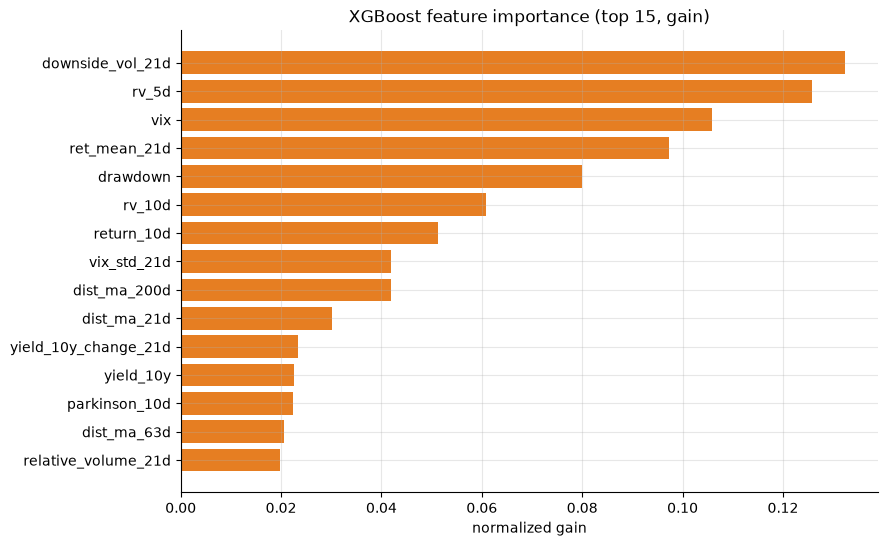

In [5]:
model = XGBoostModel(params=best_params).fit(
    pd.concat([train, val])[features], pd.concat([train, val])["rv_5d_forward"])
imp = model.feature_importance().head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index, imp.values, color="#e67e22")
ax.set_title("XGBoost feature importance (top 15, gain)")
ax.set_xlabel("normalized gain");

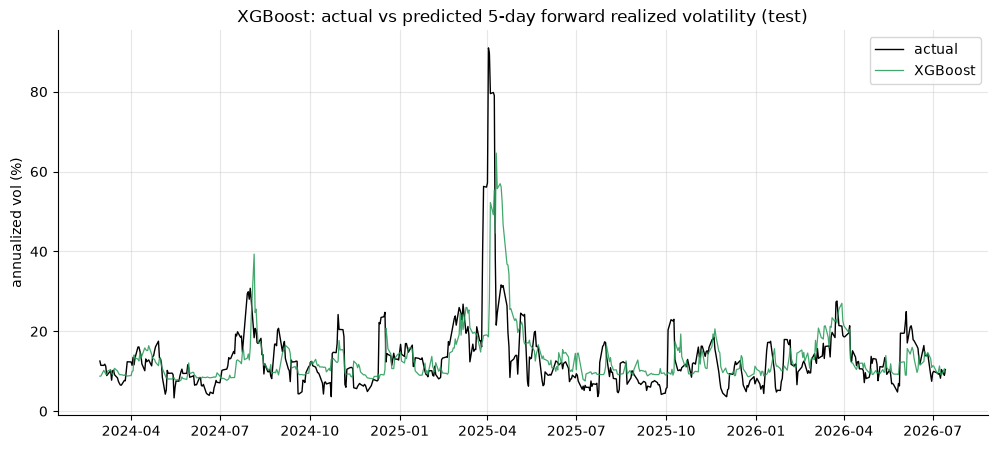

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_test.index, y_test * 100, color="black", lw=1.0, label="actual")
ax.plot(y_test.index, pred_xgb.loc[y_test.index] * 100, color="#229954", lw=0.9,
        alpha=0.85, label="XGBoost")
ax.set_title("XGBoost: actual vs predicted 5-day forward realized volatility (test)")
ax.set_ylabel("annualized vol (%)"); ax.legend();